<a href="https://colab.research.google.com/github/fitzsimmons24/ES2245/blob/main/ES2245_lab9_MarkFitz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 9: Statistical and Spectral Analysis in Geophysics
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Topics** Non-Parametric Tests, Time-Domain, and Frequency-Domain Analysis


**Objective:** Apply concepts from Lectures 21 and 22 to analyze geological and seismic data.
1. **Lecture 21 Focus:** Non-parametric statistics (Friedman, Spearman) and Time-domain analysis (Moving averages, Aliasing, Correlation).
2. **Lecture 22 Focus:** Frequency-domain analysis (FFT, PSD), Spectrograms, and digital filtering.

In [19]:
#Run this line once, you will have to reload lab, then you can comment this out
# !pip install obspy

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
import obspy
from obspy.clients.fdsn import Client

# Set plot style for the notebook
plt.rcParams['figure.figsize'] = [10, 6]
%matplotlib inline

## Task 1: Non-Parametric Comparisons (Friedman Test)
**Concept:** When data doesn't follow a normal distribution, we use the Friedman test to compare 3+ related samples.
**Scenario:** You have 5 rock samples. You measure their permeability ($mD$) under three different confining pressures (10MPa, 20MPa, 30MPa). Does pressure significantly change permeability?

In [21]:
# Data: Rows are rock samples, Columns are pressure levels
perm_data = np.array([
    [15.2, 14.8, 13.9], # Sample 1
    [10.1, 9.5, 8.2],   # Sample 2
    [25.4, 24.1, 23.0], # Sample 3
    [5.5, 5.0, 4.1],    # Sample 4
    [18.9, 17.5, 16.2]  # Sample 5
])

# I don't need statistics to see the clear trend of pressure decreasing permeability as pressure increases

# Run the Friedman test on the three related pressure groups
# Each column is one pressure condition across the same 5 rock samples
result = stats.friedmanchisquare(perm_data[:, 0], perm_data[:, 1], perm_data[:, 2])

# Print the test statistic and p-value
print("Friedman test statistic:", result.statistic)
print("p-value:", result.pvalue)

# Check whether the result is statistically significant
if result.pvalue < 0.05:
    print("There is a significant difference in permeability across pressure levels.")
else:
    print("There is not a significant difference in permeability across pressure levels.")

Friedman test statistic: 10.0
p-value: 0.006737946999085468
There is a significant difference in permeability across pressure levels.


##Task 2: Spearman Rank Correlation

**Concept:** Use Spearman's $\rho$ to find monotonic relationships between variables that are not necessarily linear (e.g., Mineral concentration vs. Depth).

In [22]:
# Depth (m) and Gold Concentration (ppm)
depth = np.array([100, 200, 300, 400, 500, 600, 700, 800])
gold_ppm = np.array([0.2, 0.5, 1.1, 2.4, 5.1, 10.2, 11.5, 12.1])

# Calculate the Spearman rank correlation and p-value
rho, p_val = stats.spearmanr(depth, gold_ppm)

print(f"Spearman correlation: {rho:.4f}")
print(f"P-value: {p_val:.4f}")

# The Spearman correlation shows a perfect positive association between depth and gold concentration
# In the sample, gold concentration always increases when depth increases

Spearman correlation: 1.0000
P-value: 0.0000


##Task 3: The Nyquist Frequency and Aliasing

**Concept:** Lecture 21 discusses Aliasing. If your sampling frequency ($f_s$) is less than twice the highest frequency in your signal ($2 \times f_{max}$), you get artifacts.

**Goal:** Create a 10 Hz sine wave. Sample it correctly (e.g., 50 Hz) and incorrectly (e.g., 12 Hz) to see aliasing.

The Nyquist frequency is 6.0 Hz. Since our signal is 10 Hz, we expect aliasing.


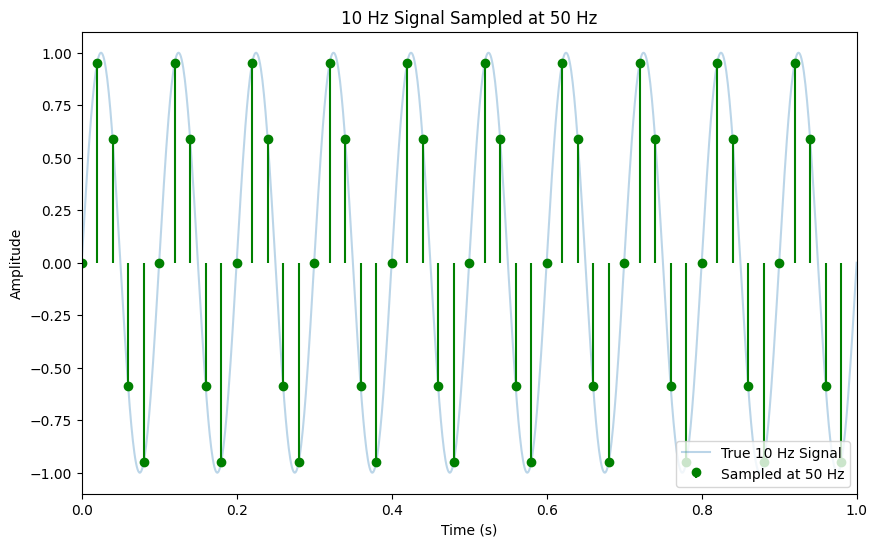

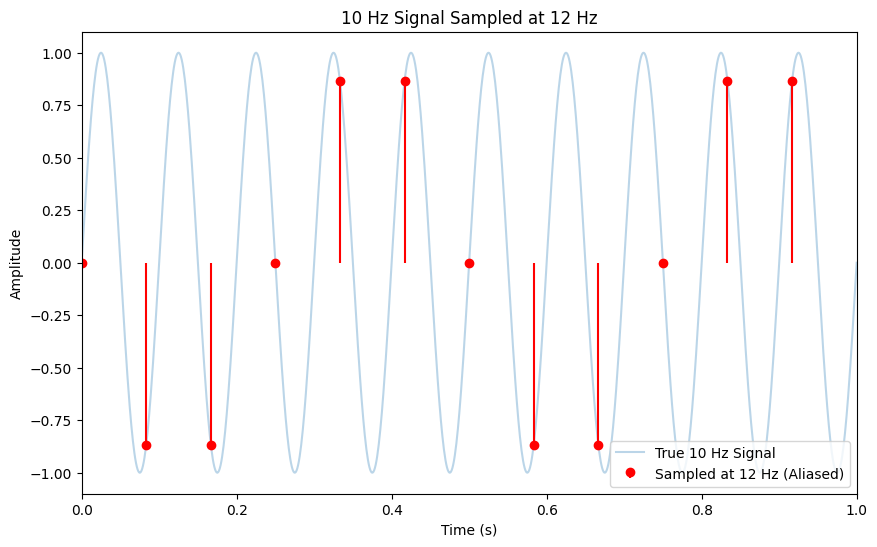

In [23]:
t_fine = np.linspace(0, 1, 1000)
f_signal = 10  # 10 Hz signal
y_true = np.sin(2 * np.pi * f_signal * t_fine)

# 50 Hz sampling rate
fs_high = 50
t_high = np.arange(0, 1, 1 / fs_high)
y_high = np.sin(2 * np.pi * f_signal * t_high)

# 12 Hz sampling rate (Aliasing!)
fs_low = 12
t_low = np.arange(0, 1, 1 / fs_low)
y_low = np.sin(2 * np.pi * f_signal * t_low)

# The Nyquist frequency is half of the sampling frequency
# The Nyquist frequency is the highest frequency that the sampled data can represent without aliasing
# This calculates the Nyquist frequency of the 12 Hz sampling rate
nyquist = fs_low / 2
print(f"The Nyquist frequency is {nyquist} Hz. Since our signal is {f_signal} Hz, we expect aliasing.")

# Plot the correctly sampled signal
plt.figure()
plt.plot(t_fine, y_true, label='True 10 Hz Signal', alpha=0.3)
plt.stem(t_high, y_high, linefmt='g-', markerfmt='go', basefmt=' ', label='Sampled at 50 Hz')
plt.title('10 Hz Signal Sampled at 50 Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, 1)
plt.legend(loc='lower right')
plt.show()

# Plot the incorrectly sampled signal to show aliasing
plt.figure()
plt.plot(t_fine, y_true, label='True 10 Hz Signal', alpha=0.3)
plt.stem(t_low, y_low, linefmt='r-', markerfmt='ro', basefmt=' ', label='Sampled at 12 Hz (Aliased)')
plt.title('10 Hz Signal Sampled at 12 Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, 1)
plt.legend(loc='lower right')
plt.show()

##Task 4: Cross-Correlation (Travel Time)

**Concept:** Cross-correlation identifies the time lag between two signals. In seismology, we use this to find the travel time of a wave between two sensors.

Detected Time Delay: 0.390 seconds


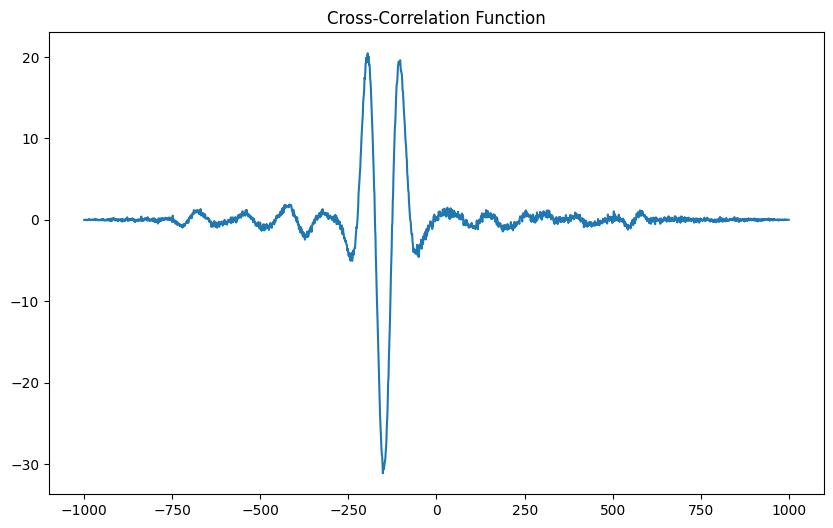

In [24]:
# Create a synthetic seismic pulse
t = np.linspace(0, 2, 1000)
def pulse(time, center):
    return np.exp(-(time-center)**2 / 0.01) * np.sin(2 * np.pi * 5 * time)

sensor1 = pulse(t, 0.5) + np.random.normal(0, 0.1, 1000)
sensor2 = pulse(t, 0.8) + np.random.normal(0, 0.1, 1000) # Delayed by 0.3s

### STUDENT CODE HERE ###
# Hint: Use np.correlate with mode='full'.
# The index of the maximum correlation value tells you the lag.

# Calculate the cross-correlation between the two sensor signals
correlation = np.correlate(sensor1, sensor2, mode='full')

# Create the lag values that match the correlation output
lags = np.arange(-len(sensor1) + 1, len(sensor1))

# Find the lag where the correlation is highest
best_lag_idx = np.argmax(correlation)

# Convert the lag from index units to seconds
time_delay = lags[best_lag_idx] * (t[1] - t[0])

print(f"Detected Time Delay: {abs(time_delay):.3f} seconds")

plt.plot(lags, correlation)
plt.title("Cross-Correlation Function")
plt.show()

## Task 5: Frequency Domain - Power Spectral Density (PSD)
**Concept:** Lecture 22 explains that a Power Spectrum pulls apart "composite" signals to reveal hidden periodicities (like the 24-hour cycle vs. 365-day cycle). In seismology, we use PSDs to distinguish between seismic events and background "ambient noise."

/usr/local/lib/python3.12/dist-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


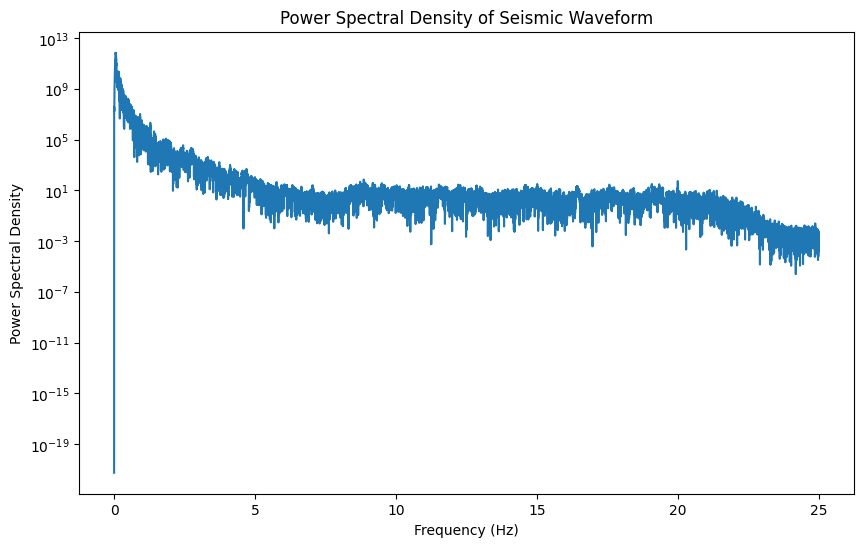

In [25]:
# Fetching data for a recent event using ObsPy
client = Client("IRIS")
starttime = obspy.UTCDateTime("2023-07-16T06:48:00") # M7.2 Alaska Event
st = client.get_waveforms("AK", "COLD", "", "BHZ", starttime, starttime + 600)
tr = st[0]

# Pre-processing: Always detrend and taper before spectral analysis
tr.detrend('linear')
tr.taper(0.05)

### STUDENT CODE HERE ###
# 1. Use scipy.signal.periodogram to calculate the PSD.
# 2. Plot the result on a log-log or semilogy scale.
# Hint: freq, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)

# Calculate the power spectral density of the waveform
freqs, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)

# Plot the PSD using a log scale on the y-axis
plt.semilogy(freqs, psd)
plt.title("Power Spectral Density of Seismic Waveform")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.show()

## Task 6: Time-Frequency Analysis - Spectrograms
**Concept:** A Power Spectrum (PSD) tells you *what* frequencies exist in the data, but a **Spectrogram** tells you *when* those frequencies occur. This is critical for identifying the arrival of different seismic phases (P-waves vs. S-waves).

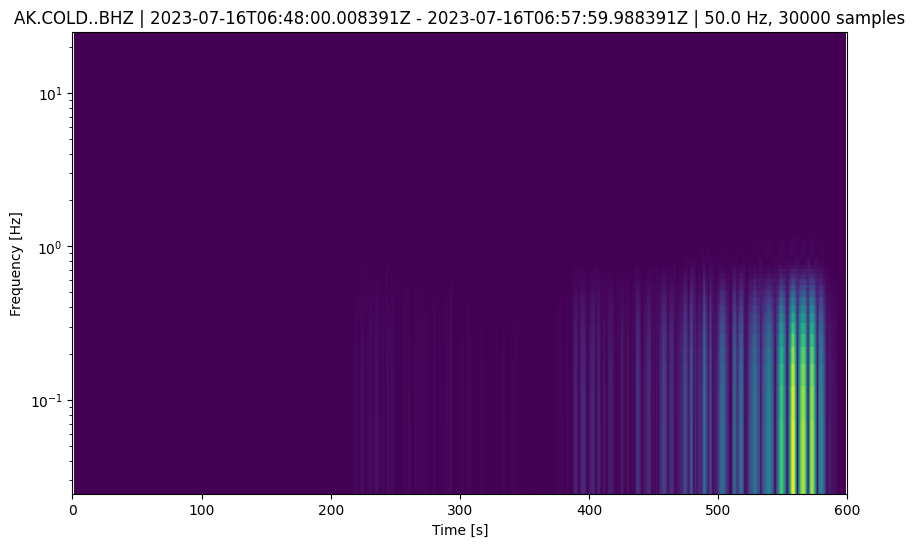

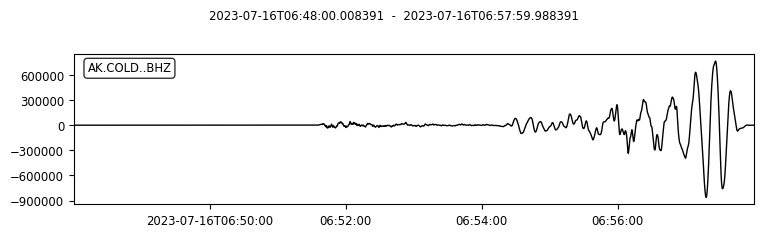

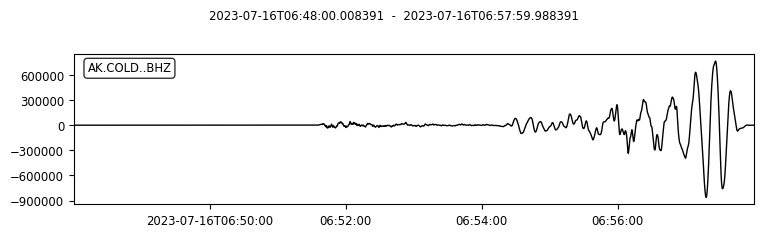

In [26]:
### STUDENT CODE HERE ###
# Hint: ObsPy Trace objects have a built-in .spectrogram() method.
# Apply it to the trace 'tr' we downloaded in the previous cell.
# Use 'log=True' in the spectrogram method to see the earthquake energy clearly.

# tr.spectrogram(...)

# Create a spectrogram of the seismic trace
# log=True makes weaker and stronger energy easier to see
tr.spectrogram(log=True)
tr.plot()

##Task 7: Wavelet Transform

**Concept** A wavelet transform is roughly equivalent to a spectrogram, except analysis is performed in the time domain.

**Task:** Write all of the code to perform a wavelet transform on the trace from Tasks 5 and 6 and plot them. Perform two different wavelet transforms for different wavelet parameters (minimum and maximum frequencies

The resource found here shows how to do this in obspy: https://docs.obspy.org/archive/stable/tutorial/code_snippets/continuous_wavelet_transform.html

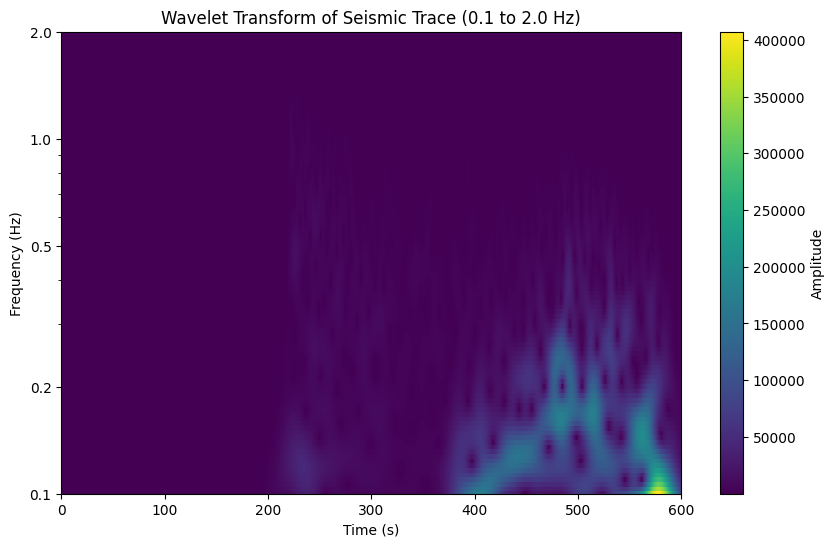

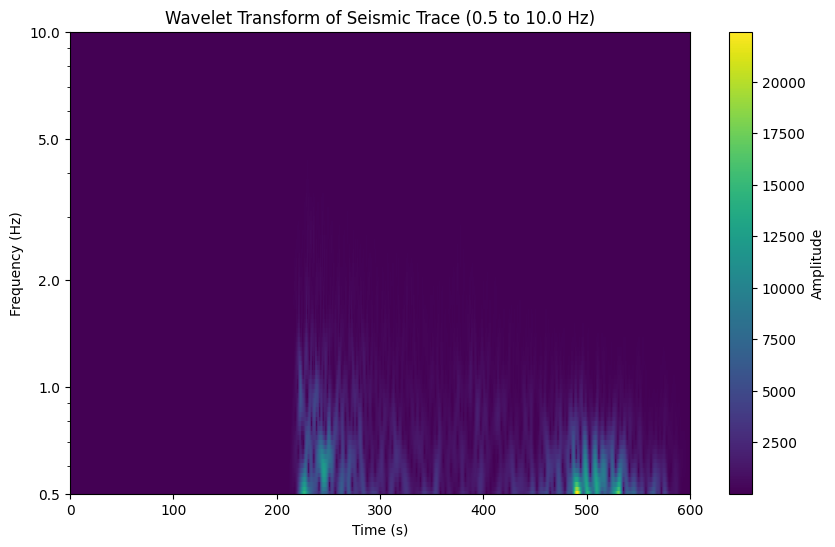

In [27]:
# Import the ObsPy wavelet transform function and colormap
from obspy.signal.tf_misfit import cwt
from obspy.imaging.cm import obspy_sequential
from matplotlib.ticker import ScalarFormatter

# Get the number of points and sample spacing from the trace
npts = tr.stats.npts
dt = tr.stats.delta

# Create a time axis in seconds
t = np.linspace(0, dt * npts, npts)

# Wavelet transform 1 for lower frequency range
f_min_1 = 0.1
f_max_1 = 2.0

# Compute the wavelet transform
scalogram1 = cwt(tr.data, dt, 8, f_min_1, f_max_1)

# Create grids for plotting
x1, y1 = np.meshgrid(
    t,
    np.logspace(np.log10(f_min_1), np.log10(f_max_1), scalogram1.shape[0])
)

# Plot the first wavelet transform
plt.figure(figsize=(10, 6))
plt.pcolormesh(x1, y1, np.abs(scalogram1), cmap=obspy_sequential, shading='auto')
plt.title("Wavelet Transform of Seismic Trace (0.1 to 2.0 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.yscale('log')
plt.ylim(f_min_1, f_max_1)
plt.yticks([0.1, 0.2, 0.5, 1, 2])
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.colorbar(label="Amplitude")
plt.show()

# Wavelet transform 2 for higher frequency range
f_min_2 = 0.5
f_max_2 = 10.0

# Compute the wavelet transform
scalogram2 = cwt(tr.data, dt, 8, f_min_2, f_max_2)

# Create grids for plotting
x2, y2 = np.meshgrid(
    t,
    np.logspace(np.log10(f_min_2), np.log10(f_max_2), scalogram2.shape[0])
)

# Plot the second wavelet transform
plt.figure(figsize=(10, 6))
plt.pcolormesh(x2, y2, np.abs(scalogram2), cmap=obspy_sequential, shading='auto')
plt.title("Wavelet Transform of Seismic Trace (0.5 to 10.0 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.yscale('log')
plt.ylim(f_min_2, f_max_2)
plt.yticks([0.5, 1, 2, 5, 10])
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.colorbar(label="Amplitude")
plt.show()

### Question 1: Power Spectra
Based on your PSD plot in Task 5, you likely see a high-energy peak at very low frequencies (below 1 Hz) and a drop-off at higher frequencies. In the context of Lecture 22, why is the frequency domain more useful than the time domain for identifying a "dominant period" in noisy data?

*The frequency domain is better because it separates the signal into frequencies. That makes the main repeating pattern easier to see, even when the data is noisy.*

### Question 2: Spectrograms
Compare the static PSD plot from Task 5 to the Spectrogram in Task 6.
* Which plot better illustrates a signal whose frequency content changes over time?
* If you see a vertical "blast" of energy across many frequencies at a specific time, what does that represent in the seismogram?

*The spectrogram is better because it shows how the frequencies change over time. A vertical blast of energy usually means a sudden event in the seismogram, like a strong seismic arrival or short burst of shaking.*

### Question 3: Wavelet Transforms
Lecture 22 mentions **Wavelet Transforms** as another technique for frequency analysis.
* **Hint:** Unlike the Fourier Transform (which uses infinite sines and cosines), Wavelets use short-duration "pulses."
* **Question:** Why might a Wavelet Transform be superior to a standard Fourier Transform for a seismic signal that contains sudden, short-lived "jolts" (like a rockfall or an explosion)?

*Wavelet transforms are better for short, sudden signals because they show both the time and frequency of the event. That makes them useful for things like explosions or rockfalls.*

### Question 4: Filtering
If you were looking for **Earth Tides** (very slow deformations with a period of ~12 hours), would you use a High-Pass or a Low-Pass filter to remove the "noise" of earthquakes and traffic? Why?

*I would use a low-pass filter because Earth tides are very low-frequency signals. Earthquakes and traffic are higher frequency, so the filter would keep the tides and remove more of the noise.*